# Фаза 1. Неделя 4
## Обучение без учителя
### Временные ряды

In [ ]:
import pandas as pd
import statsmodels as sm
import matplotlib.pyplot as plt
import numpy as np
import datetime
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (18, 5)

In [ ]:
# Загружаем данные, ставим в индекс колонку с датой, указыываем аргумент parse_dates
df = pd.read_csv('/content/sample_data/monthly-milk-production.csv',
                 sep=';',
                 index_col=['month'],
                 parse_dates=['month'],
                 dayfirst=True
                )

In [ ]:
df

,milk
month,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727
...,...
1975-08-01,858
1975-09-01,817
1975-10-01,827


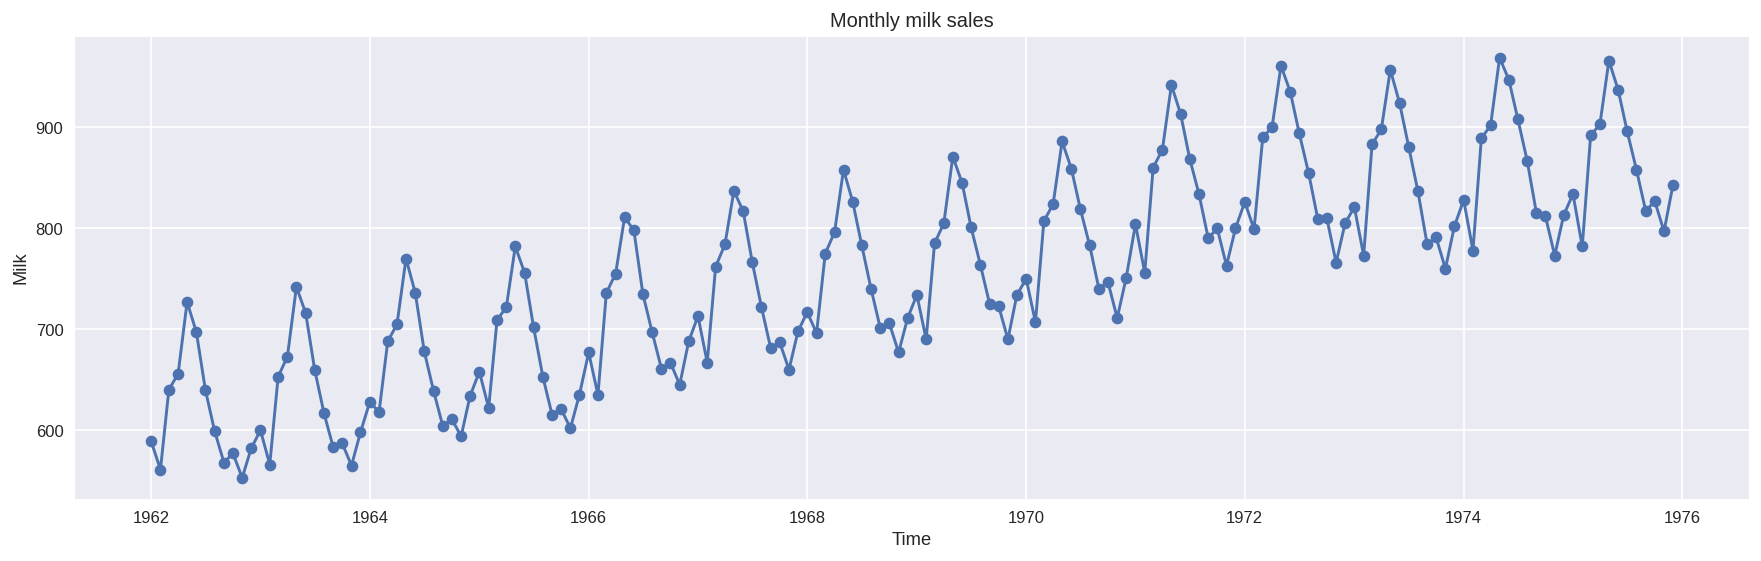

In [ ]:
plt.plot(df['milk'], marker='o')
plt.xlabel('Time')
plt.ylabel('Milk')
plt.title('Monthly milk sales');

In [ ]:
# Обращаем внимание: тип индекса datetime64[ns]
df.index

DatetimeIndex(['1962-01-01', '1962-02-01', '1962-03-01', '1962-04-01',
               '1962-05-01', '1962-06-01', '1962-07-01', '1962-08-01',
               '1962-09-01', '1962-10-01',
               ...
               '1975-03-01', '1975-04-01', '1975-05-01', '1975-06-01',
               '1975-07-01', '1975-08-01', '1975-09-01', '1975-10-01',
               '1975-11-01', '1975-12-01'],
              dtype='datetime64[ns]', name='month', length=168, freq=None)

In [ ]:
# выбрать сэмпл с определенным годом
df.loc[df.index.year == 1975]

,milk
month,
1975-01-01,834
1975-02-01,782
1975-03-01,892
1975-04-01,903
1975-05-01,966
1975-06-01,937
1975-07-01,896
1975-08-01,858
1975-09-01,817


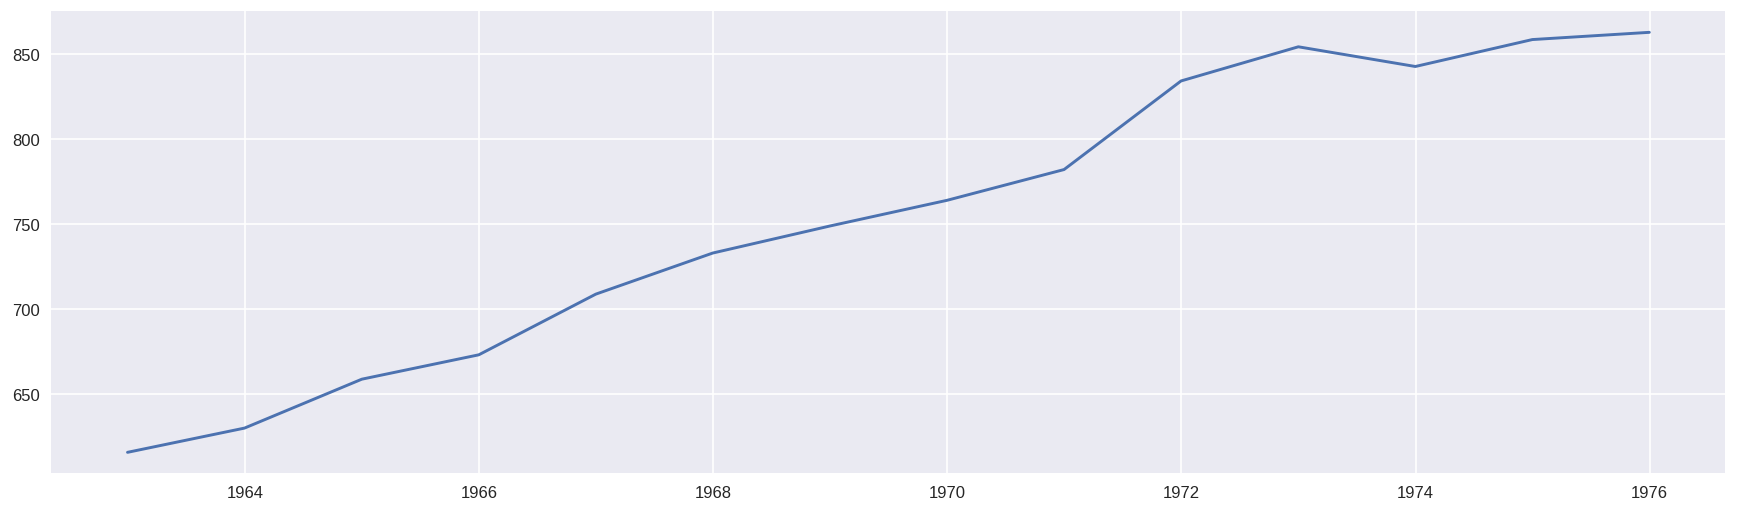

In [ ]:
# resample позоволяет взять выборку по определенному интервалу и посчитать необходимую статистику
# display(df.resample('Y').sum())
# display(df.resample('Y').mean())
plt.plot(df.resample('Y').mean());

### 1.1 Скользящее среднее / Moving Average

$\hat{y}_{t} = \dfrac{1}{k} \displaystyle\sum^{k-1}_{n=0} y_{t-n}$

In [ ]:
df.head()

,milk
month,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


In [51]:
df.shape

(168, 1)

* Попробуем скользящее окно размером 1. а-ля предсказание вида "Завтра будет как вчера"

In [ ]:
# Параметр окна для скользящего среднего.
# При n_window = 1 это наивный прогноз "вчерашним значением".
# Поставьте >1 (например, 3, 7, 12), чтобы было настоящее усреднение по прошлым точкам.
n_window = 1

# Берём целевую серию и гарантируем числовой тип (нечисловые превратятся в NaN).
y = pd.to_numeric(df['milk'], errors='coerce')

# ВАЖНО: rolling(...).mean() по умолчанию включает текущую точку,
# что даёт "подглядывание в будущее" при оценке качества.
# Поэтому мы считаем среднее по прошлым n_window значениям и смещаем его на 1 шаг назад:
ma_pred = (
    y.rolling(window=n_window, min_periods=n_window)  # берём окно длиной n_window; значение появится только когда точек достаточно
     .mean()                                          # считаем среднее по окну
     .shift(1)                                        # СМЕЩАЕМ на 1: прогноз для момента t основан только на данных < t
)

# Создаём маску валидных позиций: где есть и факт, и предсказание (без NaN).
# В начале ряда после shift(1) будут NaN — их исключаем из расчёта метрик.
mask = ma_pred.notna() & y.notna()

# Считаем метрики на совпадающих валидных позициях.
moving_average_mae = np.round(mean_absolute_error(y[mask], ma_pred[mask]), 2)
moving_average_r2  = np.round(r2_score(y[mask], ma_pred[mask]), 2)

# Для совместимости с вашим неймингом — так же можно сохранить предсказания в ту же переменную:
moving_average_pred = ma_pred

# (опционально) вывести результат
print(f"MAE: {moving_average_mae}, R²: {moving_average_r2}")

# --- ПОДСКАЗКИ ---
# 1) Если индекс df — DatetimeIndex и вы хотите окно по времени, используйте, например:
#    ma_pred = y.rolling('7D', min_periods=1).mean().shift(1)
#    Это среднее за последние 7 дней БЕЗ текущего дня благодаря shift(1).
#
# 2) Если длина ряда <= n_window, метрики не посчитаются (слишком мало точек) — уменьшите окно или увеличьте ряд.
#
# 3) При n_window=1: ma_pred == y.shift(1).
#    Это baseline-модель. R² может быть отрицательным — это нормально для простых наивных прогнозов.

MAE: 39.01, R²: 0.8


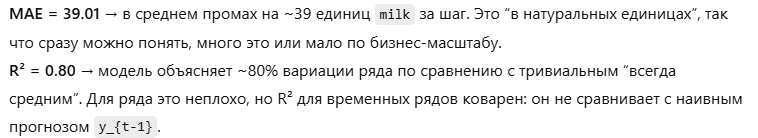

'MAE = 39.01'

'r2 = 0.8'

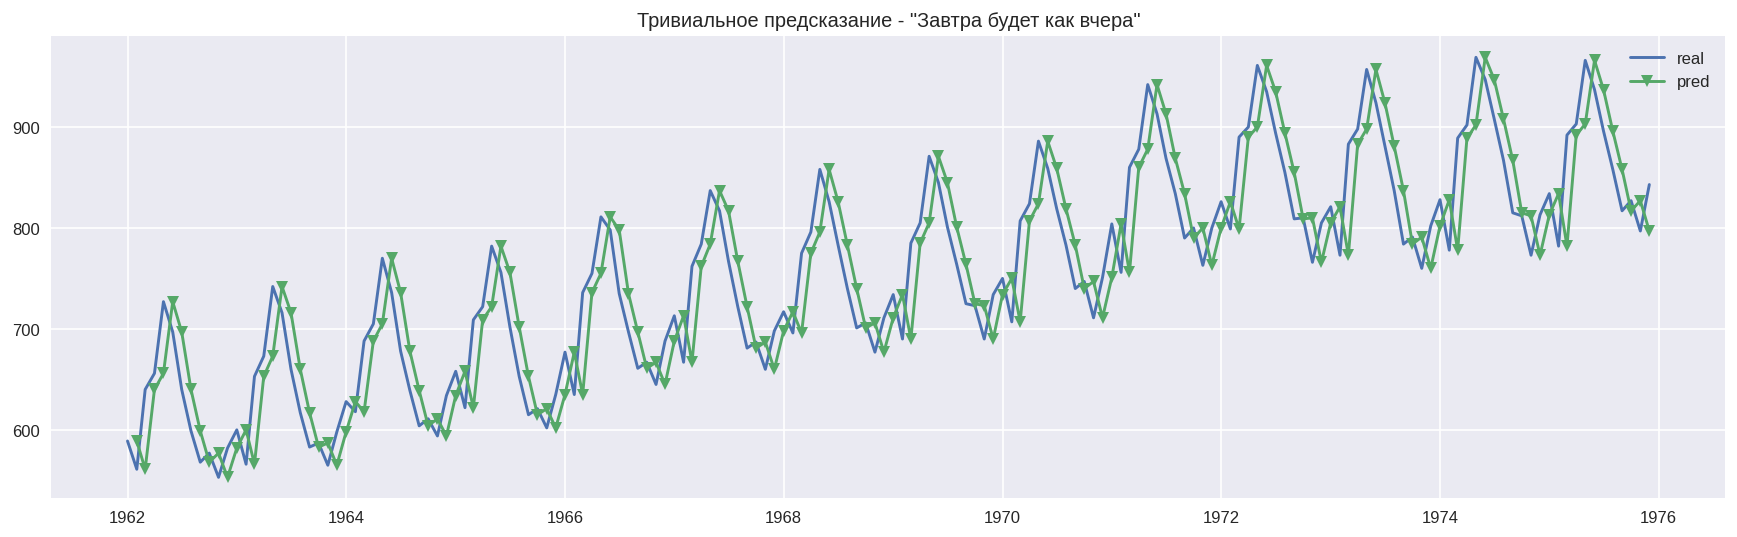

In [ ]:
display(f'MAE = {moving_average_mae}')
display(f'r2 = {moving_average_r2}')
plt.plot(df['milk'], label='real')
plt.plot(moving_average_pred, label='pred', marker='v')
plt.legend()
plt.title(f'Тривиальное предсказание - "Завтра будет как вчера"');

* Посмотрим для окон разных размеров

In [ ]:
# перебираем размеры окна для скользящего среднего
n_windows = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

for n_window in n_windows:
    # собираем датафрейм с фактом и прогнозом:
    # 'pred' — скользящее среднее по окну n_window
    # ВАЖНО: при целочисленном окне .rolling(..., closed='left') фактически не исключает текущую точку,
    # поэтому среднее включает текущее значение => возможен "подгляд" (оптимистичный MAE).
    rolling_pred = pd.DataFrame(data={
        'act': df['milk'],
        'pred': df['milk'].rolling(window=n_window, closed='left').mean()
    })

    # считаем MAE, обрезая первые n_window наблюдений:
    # так убираем начальные NaN у скользящего среднего и выравниваем длины рядов
    mae = np.round(mean_absolute_error(rolling_pred['act'][n_window:], rolling_pred['pred'][n_window:]), 2)

    # выводим качество для каждого размера окна
    print(f'Для скользящего окна размером {n_window}, MAE = {mae}')

Для скользящего окна размером 1, MAE = 39.01
Для скользящего окна размером 2, MAE = 45.08
Для скользящего окна размером 3, MAE = 52.78
Для скользящего окна размером 4, MAE = 59.77
Для скользящего окна размером 5, MAE = 61.9
Для скользящего окна размером 6, MAE = 64.3
Для скользящего окна размером 7, MAE = 66.06
Для скользящего окна размером 8, MAE = 66.37
Для скользящего окна размером 9, MAE = 64.27
Для скользящего окна размером 10, MAE = 60.29
Для скользящего окна размером 11, MAE = 55.77
Для скользящего окна размером 12, MAE = 51.28
Для скользящего окна размером 13, MAE = 48.66
Для скользящего окна размером 14, MAE = 47.49
Для скользящего окна размером 15, MAE = 48.22


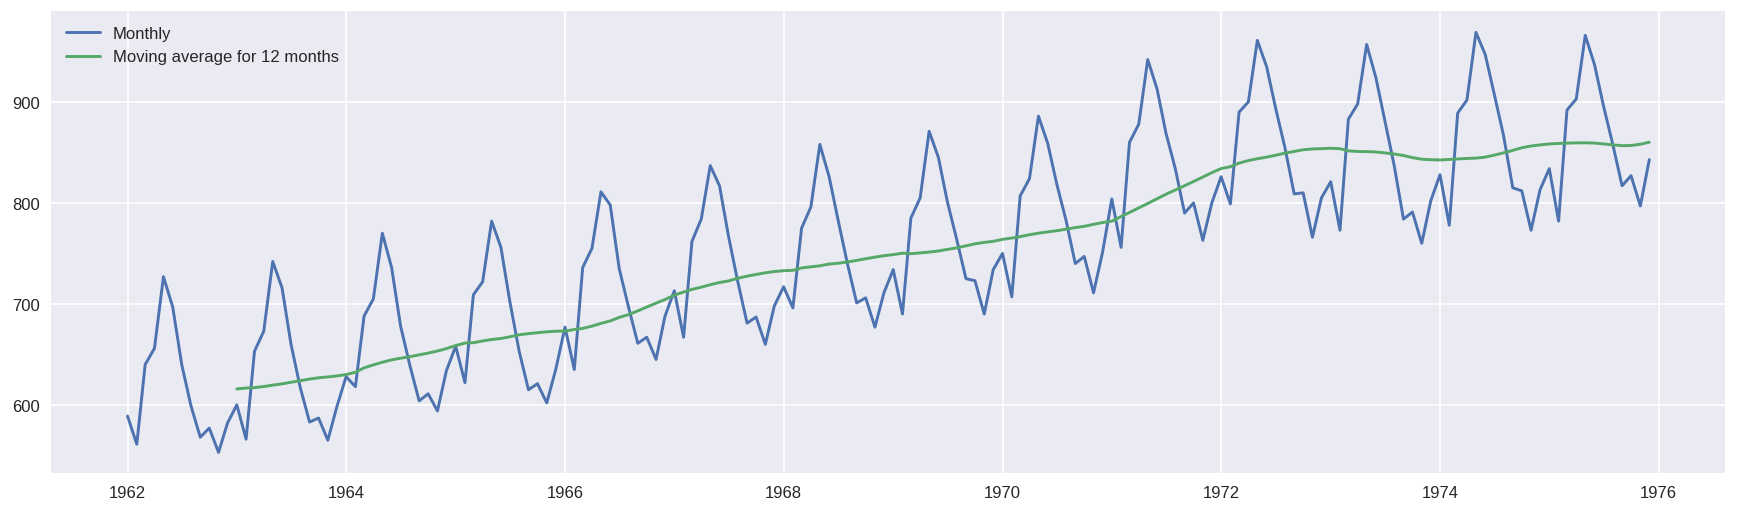

In [ ]:
# годовое окно сглаживания (12 месяцев)
n_months = 12

# фактический помесячный ряд
plt.plot(df['milk'], label='Monthly')

# скользящее среднее по окну n_months
# ВАЖНО: для целочисленного окна параметр closed='left' фактически не исключает текущую точку,
# поэтому текущее значение входит в среднее (без смещения).
# (Если нужно использовать только прошлые значения, обычно добавляют .shift(1) — код не меняем.)
plt.plot(
    df['milk'].rolling(window=n_months, closed='left').mean(),
    label=f'Moving average for {n_months} months'
)

plt.legend();

### 1.2 Взвешенное скользящее среднее / Weighted moving average

$\hat{y}_{t} = \displaystyle\sum^{k}_{n=1} \omega_n y_{t+1-n}$

In [ ]:
# Функция взвешенного скользящего среднего; веса нормируются внутри.
def weighted_moving_average(x, n, weights):
    """
    Взвешенное скользящее среднее (WMA) по окну длины n.
    - x: pd.Series с числовыми данными.
    - n: размер окна (ДОЛЖЕН совпадать с длиной weights).
    - weights: список/массив весов; convention: weights[0] — самый старый, weights[-1] — самый свежий в окне.
    Возвращает ряд, сдвинутый на 1 шаг, т.е. значение в момент t рассчитано только из данных < t (без подглядывания).
    Примечания:
      * Первые n значений после shift будут NaN — это ожидаемо.
      * Если sum(weights) == 0 — будет деление на ноль.
      * Здесь индекс берётся из глобального df.index; если x имеет другой индекс, они могут не совпасть.
    """
    weights = np.array(weights)  # приводим веса к numpy-массиву (для dot и суммирования)

    # считаем WMA по скользящему окну: для каждого окна длины n берём скалярное произведение x·w,
    # делим на сумму весов => нормированное среднее
    wmas = x.rolling(n).apply(
        lambda x: np.dot(x, weights) / weights.sum(),  # нормировка на сумму весов
        raw=True  # rolling передаёт в лямбду numpy-массив, а не Series — быстрее
    ).to_list()  # превращаем в список (ниже соберём обратно в Series)

    # оформляем результат в Series с тем же индексом df и смещаем на 1 шаг,
    # чтобы использовать только прошлые значения при прогнозе текущего
    result = pd.Series(wmas, index=df.index).shift(1)

    return result

In [ ]:
n_window = 12  # размер окна в месяцах; ДОЛЖЕН совпадать с длиной списка weights

# задаём веса окна:
#  - 0.7 для значения ровно 12 месяцев назад,
#  - следующие десять месяцев по 0.01 (в сумме 0.1),
#  - 0.2 для последнего (самого свежего) месяца в окне.
# сумма весов = 1.0 (нормировка всё равно делается в функции)
weights = [0.7] * 1 + [0.1 / 10] * 10 + [0.2] * 1

# считаем взвешенное скользящее среднее:
# функция внутри делает shift(1), т.е. прогноз на t использует только данные < t (без подглядывания)
weighted_moving_average_pred = weighted_moving_average(df['milk'], n=n_window, weights=weights)

# MAE по валидным точкам:
# первые n_window значений предикта NaN из-за rolling+shift; срез [n_window:] выравнивает ряды
weighted_moving_average_mae = np.round(
    mean_absolute_error(
        df['milk'][n_window:],
        weighted_moving_average_pred[n_window:]
    ),
    2
)

# R² по тем же выровненным срезам (доля объяснённой вариации относительно среднего)
weighted_moving_average_r2 = np.round(
    r2_score(
        df['milk'][n_window:],
        weighted_moving_average_pred[n_window:],
    ),
    2
)

# выводим метрики (в ноутбуке display покажет строки)
display(f'MAE = {weighted_moving_average_mae}')
display(f'r2 = {weighted_moving_average_r2}')

'MAE = 18.88'

'r2 = 0.94'

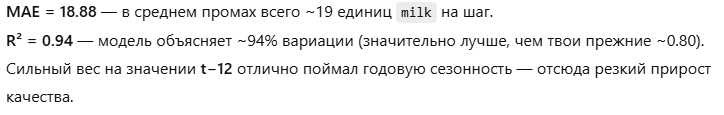

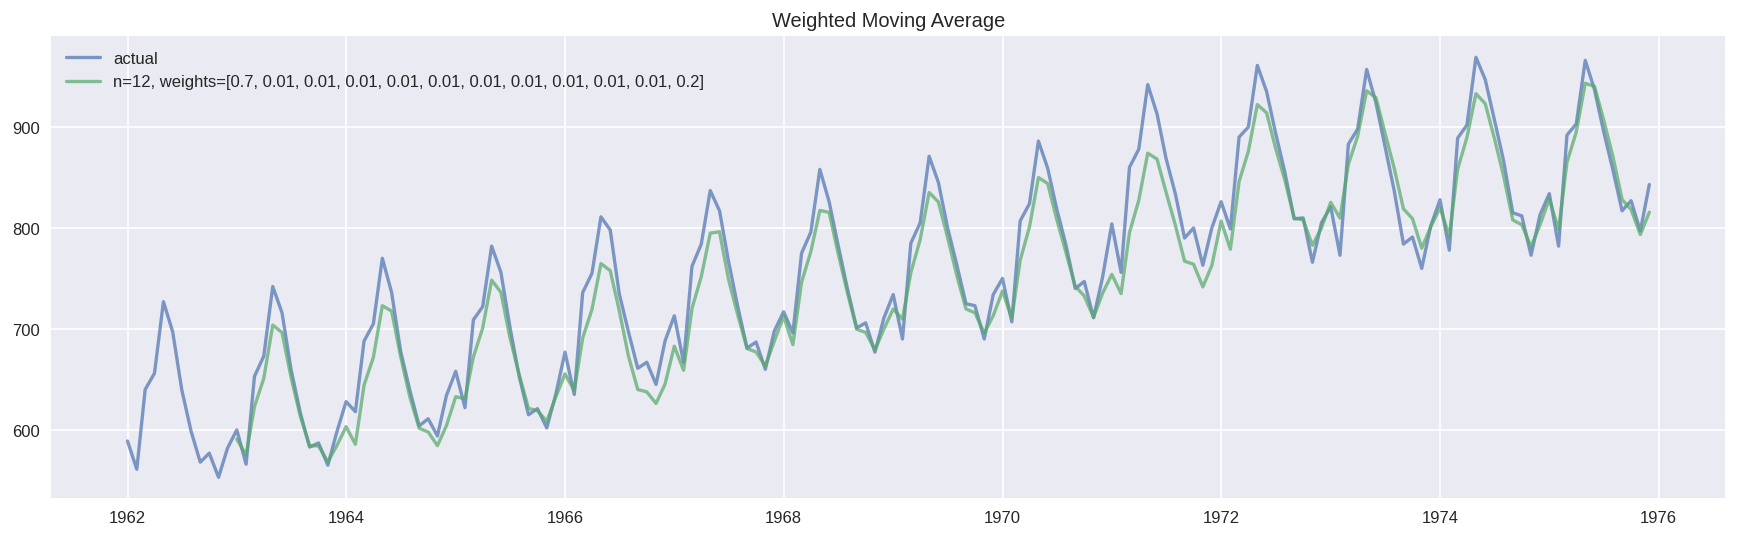

In [ ]:
plt.plot(
    df['milk'],
    linewidth=2,
    label='actual',
    alpha=.7
)

plt.plot(
    weighted_moving_average_pred,
    linewidth=2,
    label=f'n={n_window}, weights={weights}',
    alpha=.7
)
plt.title('Weighted Moving Average')
plt.legend();

* Оптимальную развесовку можно попробовать найти через __optuna__, __scipy__, или описать поиск вручную

### 2.5 Автокорреляция

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

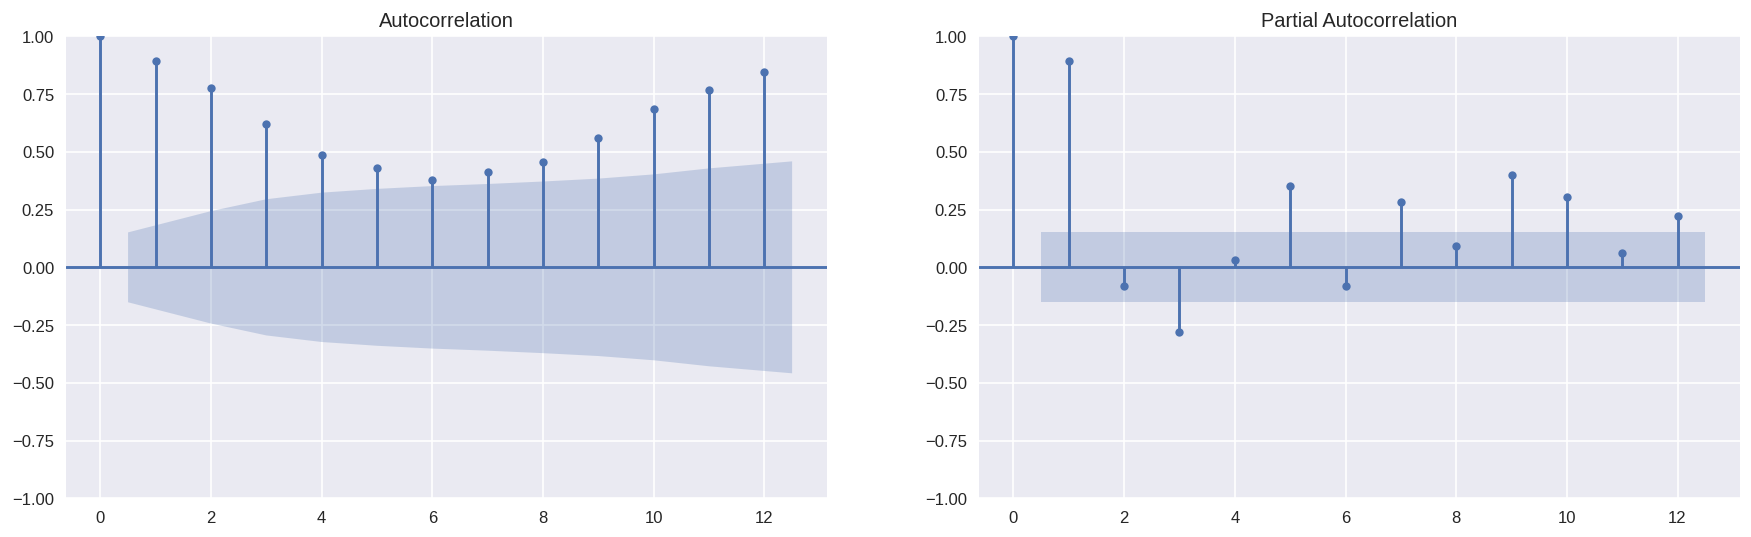

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2)
n_lags = 12
acf = plot_acf(df['milk'], ax=ax1, lags=n_lags)
pacf = plot_pacf(df['milk'], ax=ax2, lags=n_lags)

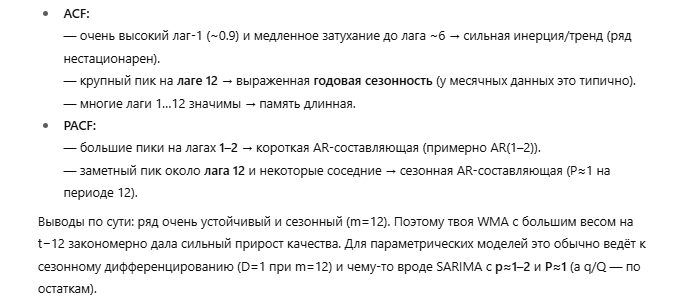

### 3. ARIMA class models

In [ ]:
from statsmodels.tsa.ar_model import AutoReg

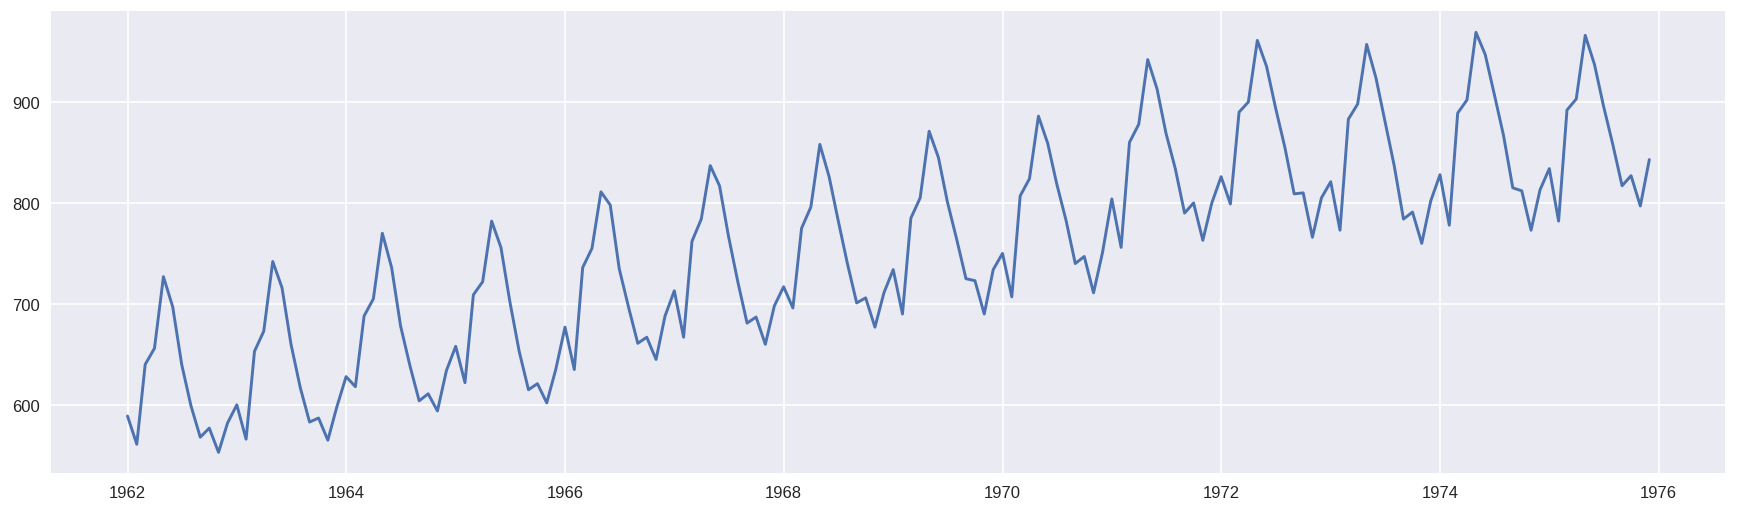

In [ ]:
plt.plot(df['milk'])

In [ ]:
data_train = df[df['milk'].index.year < 1974]
data_test = df[df['milk'].index.year >= 1974]

In [ ]:
# AR-модель с 12 лагами: текущее значение объясняется 12 предыдущими наблюдениями (AR(12))
lags = 12

# обучаем авторегрессию на train; по умолчанию в модели есть константа (trend='c')
# предпосылка: ряд примерно стационарен; сезонность частично ловится лагом 12
ar = AutoReg(data_train, lags=lags).fit()

# длина сезонности (месяцев) — используем ниже только для задания горизонта прогноза
seasonality_period = 12

# in-sample предсказания по train (начиная с момента t = lags)
# удобно для диагностики подгонки/остатков
ar_pred_train = ar.fittedvalues  # предсказания для train

# строим out-of-sample прогноз: на длину теста + ещё 3 сезона вперёд
# .forecast(h) даёт h последовательных одношаговых прогнозов сразу после конца train
ar_pred = ar.forecast(len(data_test) + 3 * seasonality_period)  # Предсказание для тестовых точек + еще на 3 сезона вперед

# разделяем: первая часть — для теста, оставшееся — «будущее» после теста
ar_pred_test, ar_pred_future = ar_pred[:len(data_test)], ar_pred[len(data_test):]  # Делим элементы из тестовой выборки и будущий период

# (закомментировано) пример, как можно было бы нарисовать сравнение с другой моделью
# plt.plot(
#     best_triple_exp.fittedvalues,
#     label=f'\u03B1 = {alpha}, \u03B2 = {betta}, \u03B3 = {gamma}; RMSE={rmse}', marker='v', color='k')

# метрики качества на тесте; важно, чтобы ar_pred_test и data_test были выровнены по порядку/индексу
ar_mae = round(mean_absolute_error(data_test, ar_pred_test), 3)
ar_r2 = round(r2_score(data_test, ar_pred_test), 3)
print(f'mae = {ar_mae}')
print(f'r2 = {ar_r2}')

mae = 12.585
r2 = 0.915


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
display('Веса авторегрессии')
ar.params

'Веса авторегрессии'

,0
const,38.482526
milk.L1,0.189520
milk.L2,0.042581
milk.L3,-0.059498
milk.L4,-0.044674
milk.L5,0.043710
milk.L6,-0.037217
milk.L7,0.057434
milk.L8,-0.082553
milk.L9,0.018573


* самый большой вес имеет сезонный лаг(этот же месяц в прошлом году), а так же прошлый месяц

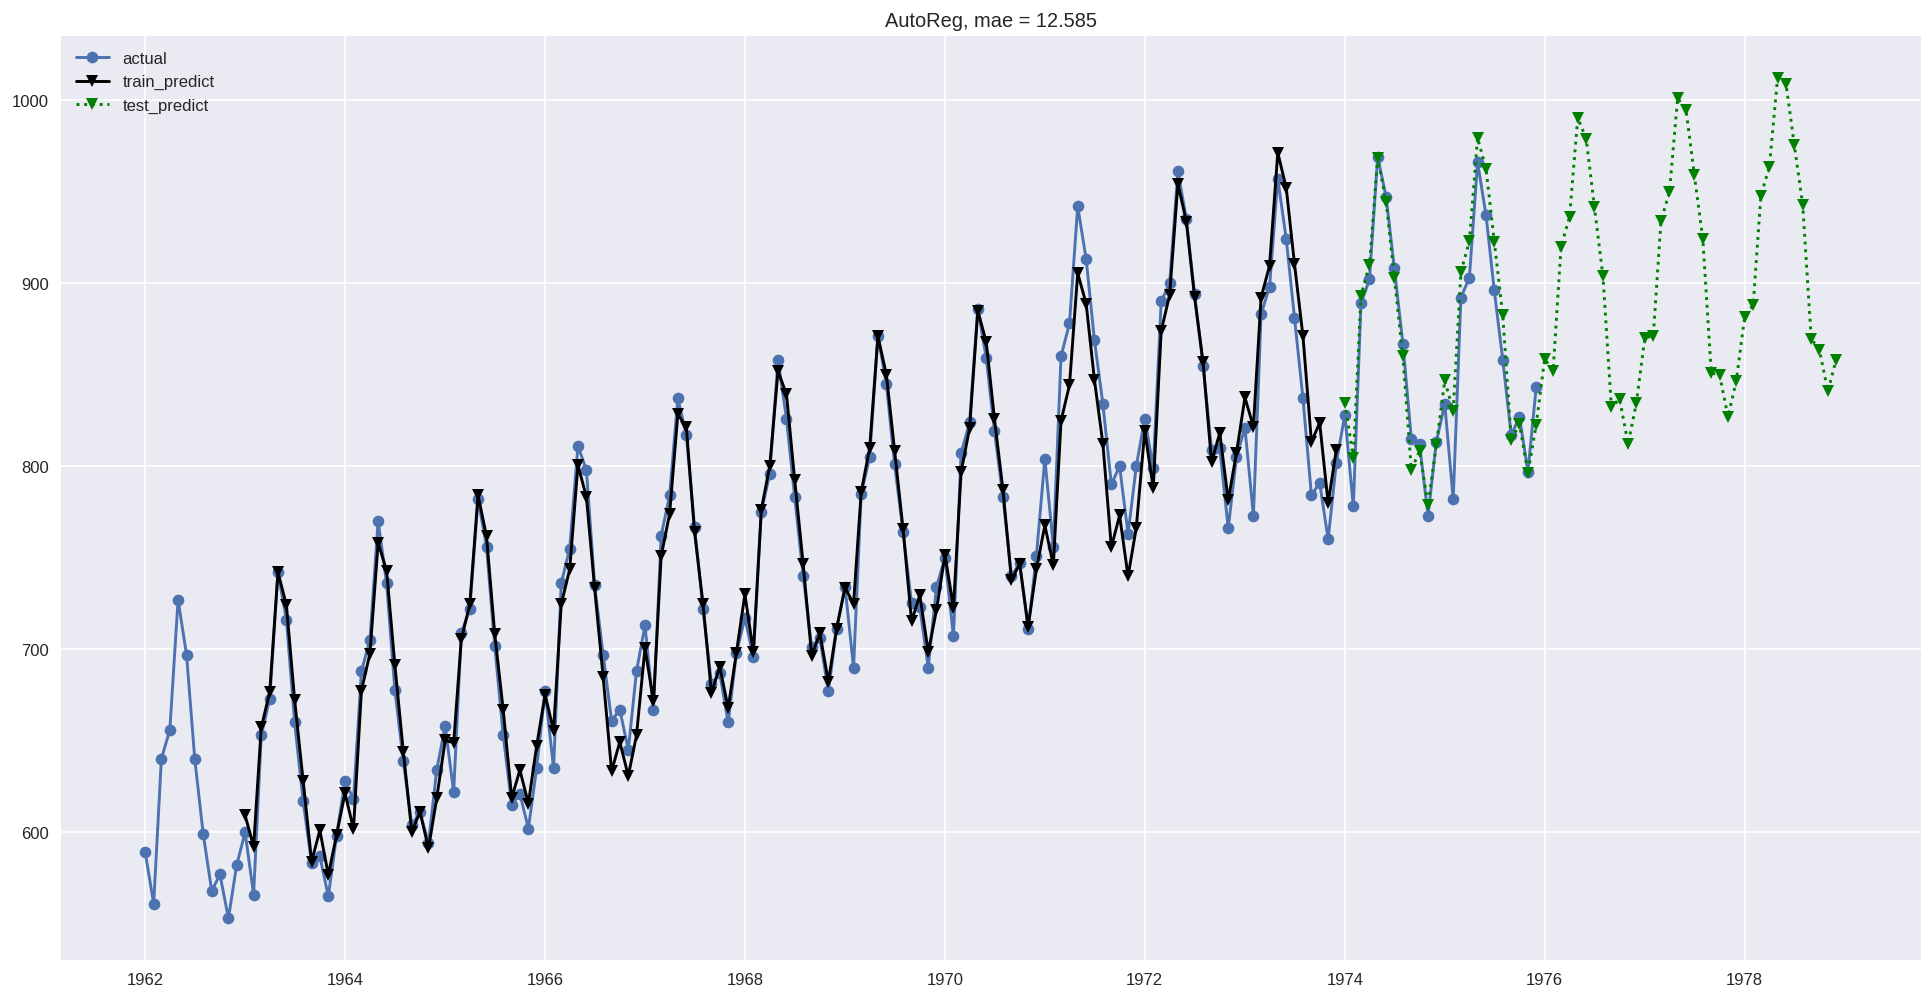

In [ ]:
plt.figure(figsize=(20, 10))
plt.plot(df['milk'], label='actual', marker='o')
plt.plot(ar_pred_train, marker='v', color='k', label='train_predict')
plt.plot(pd.concat((ar_pred_test, ar_pred_future)), marker='v', color='g', label='test_predict', linestyle=':')
plt.legend()
plt.title(f'AutoReg, mae = {ar_mae}');

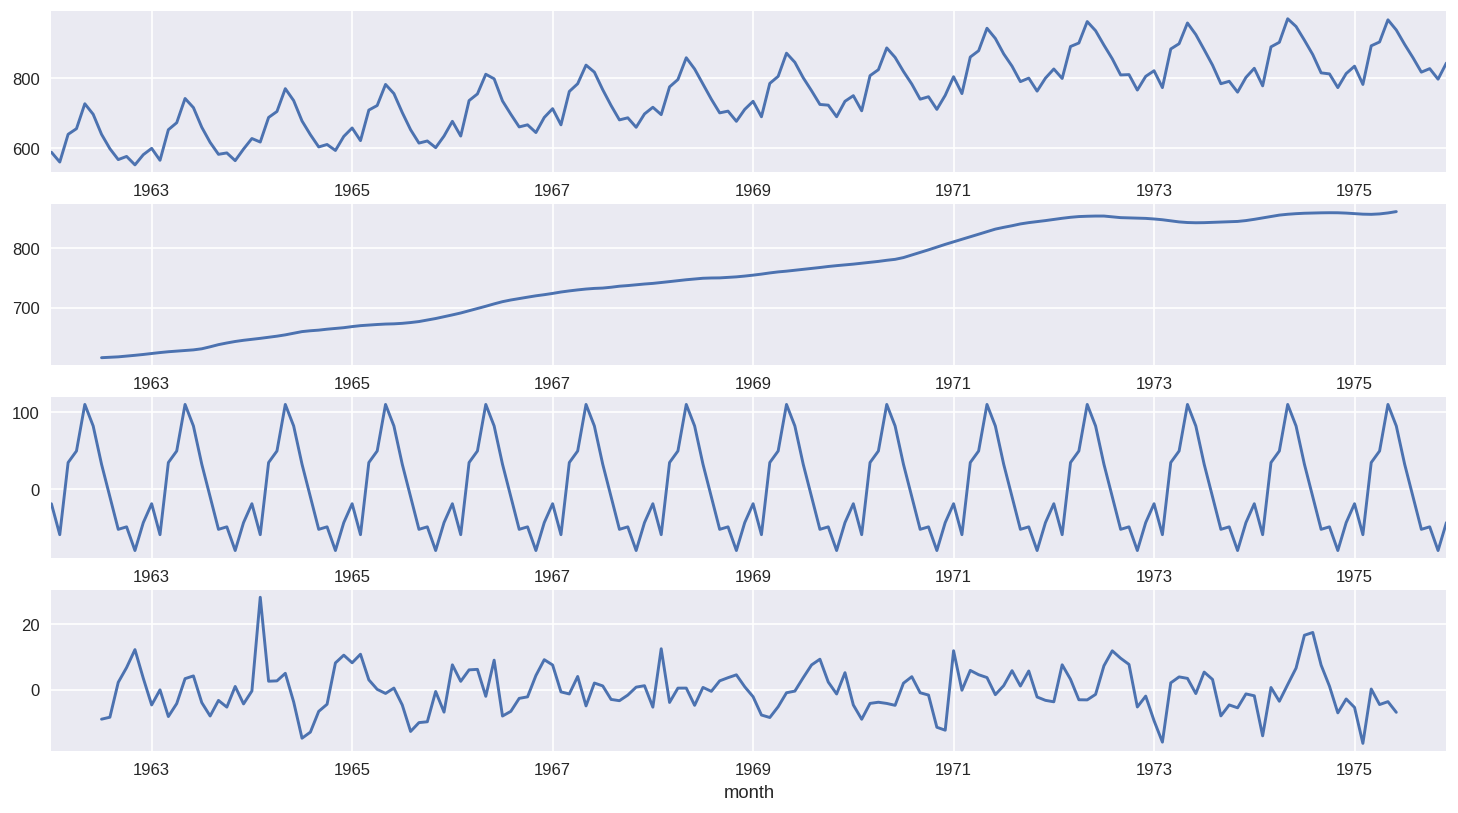

In [ ]:
# Функция разложения временного ряда на тренд, компоненты сезонности и остатки (ошибки)
from statsmodels.tsa.seasonal import seasonal_decompose

fig, (ax1,ax2,ax3, ax4) = plt.subplots(4,1, figsize=(15,8))
res = seasonal_decompose(df['milk'])
res.observed.plot(ax=ax1)
res.trend.plot(ax=ax2)
res.seasonal.plot(ax=ax3)
res.resid.plot(ax=ax4)
plt.show();

### 4. Prophet

In [ ]:
from prophet import Prophet

$y(t) = g(t) + s(t) + h(t) + \epsilon (t)$

$g(t)$ - трендовая компонента  
$s(t)$ - сезонная компонента  
$h(t)$ - компонента праздников или других всплесков  
$\epsilon (t)$ - остаток(шум)

* Одна из самых популярных моделей на текущей момент
* Не всегда проста в настраивании
* Вклад каждой из компонент будет расчитываться автоматически (не полезем вовнутрь, там ряды фурье😰)
* Некоторое воздействие на каждую из компонент все же есть
* [документация](https://facebook.github.io/prophet/docs/quick_start.html)

In [ ]:
data_prophet = df['milk'].reset_index().rename(columns={'month': 'ds', 'milk': 'y'}) # Обязательное имена колнок с датой и таргетотм в prophet


data_train = data_prophet[data_prophet['ds'].dt.year < 1974]
data_test = data_prophet[data_prophet['ds'].dt.year >= 1974]

In [ ]:
model = Prophet()
model.fit(data_train)

seasonality_period = 12
number_of_future_predicted_points = 5 * seasonality_period # Предскажем на три периода в тесте + пару периодов наперед

future = model.make_future_dataframe(periods=number_of_future_predicted_points, freq='M')
forecast = model.predict(future)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpuv0i6y00/uxc7m7_b.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpuv0i6y00/2d5vqpeu.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=40870', 'data', 'file=/tmp/tmpuv0i6y00/uxc7m7_b.json', 'init=/tmp/tmpuv0i6y00/2d5vqpeu.json', 'output', 'file=/tmp/tmpuv0i6y00/prophet_modelg2r_e1wr/prophet_model-20250903051213.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
05:12:13 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
05:12:13 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


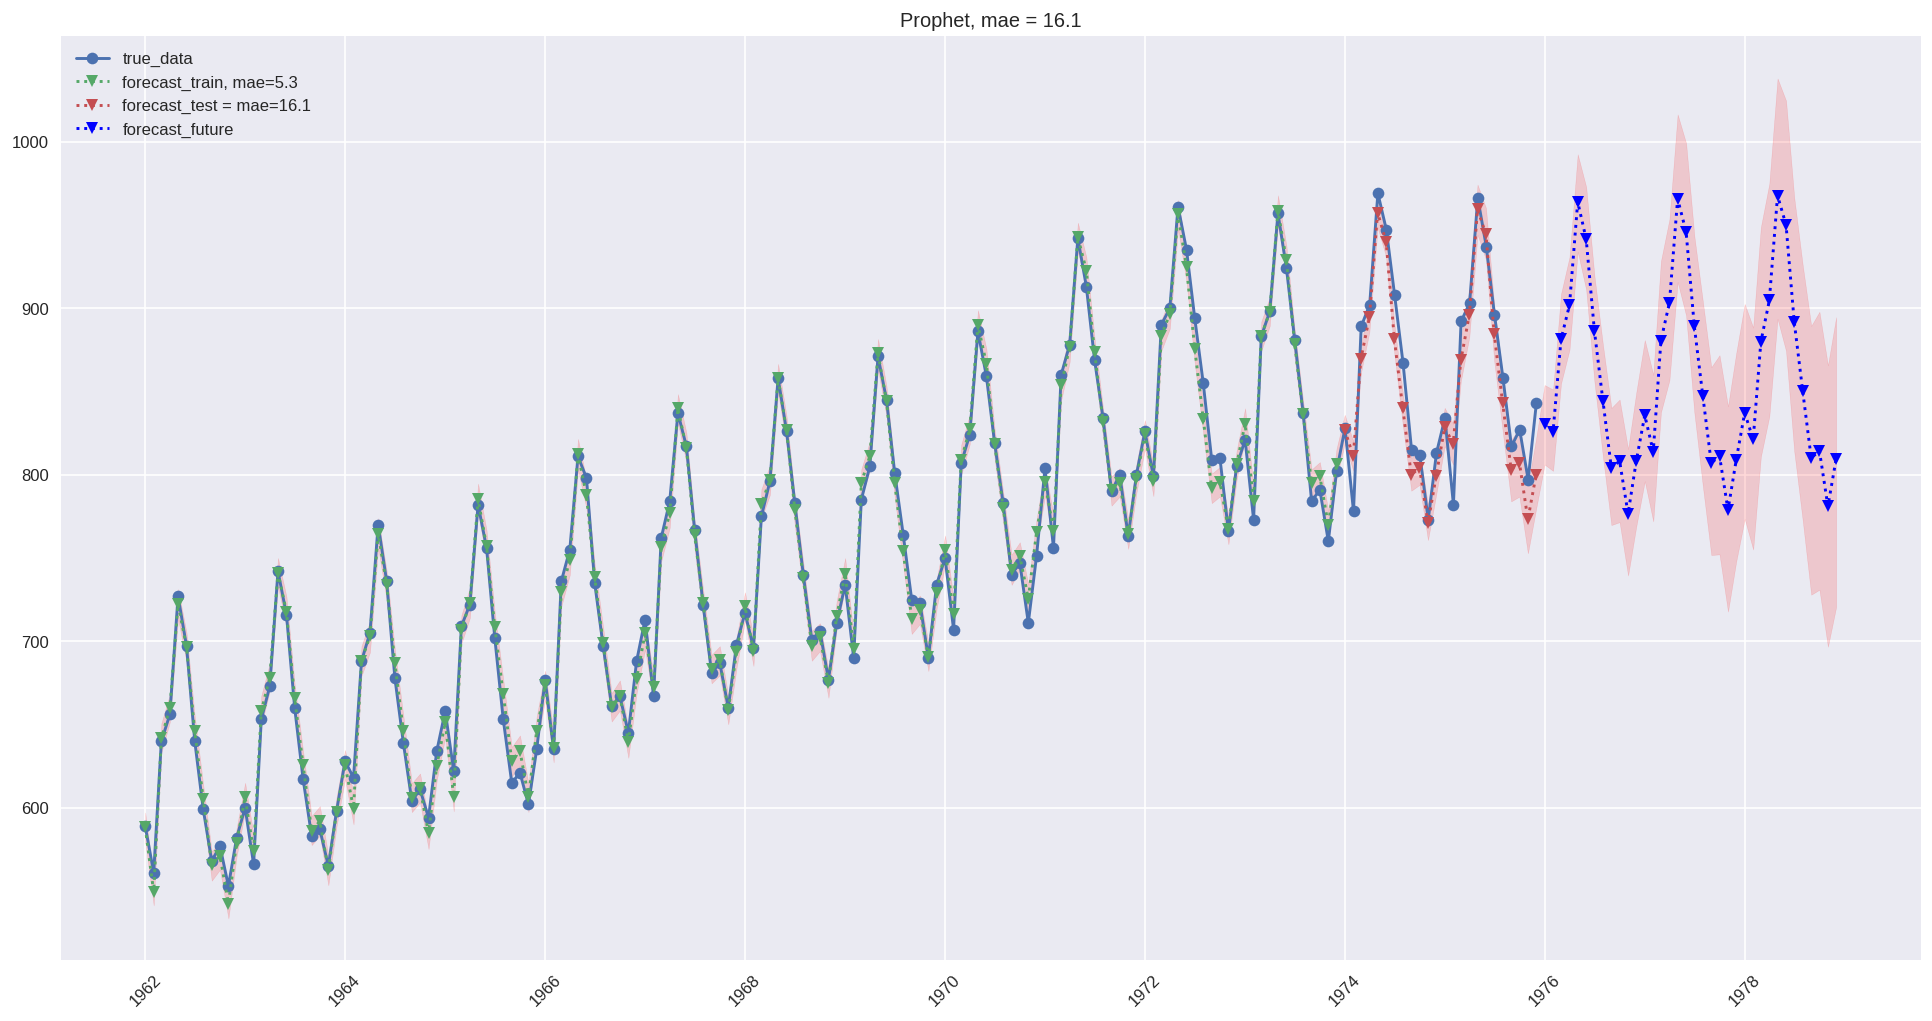

In [ ]:
forecast_train = forecast[:-number_of_future_predicted_points] # Трейновый период
forecast_test = forecast[-number_of_future_predicted_points: -number_of_future_predicted_points + len(data_test)] # Тестовый
forecast_future = forecast[-number_of_future_predicted_points + len(data_test):] # Будущий период


prophet_mae_train = np.round(mean_absolute_error(data_train['y'], forecast_train['yhat']), 1)
prophet_mae_test = np.round(mean_absolute_error(data_test['y'], forecast_test['yhat']), 1)

plt.figure(figsize=(20, 10))
plt.plot(df['milk'], label='true_data', marker='o')

plt.plot(forecast_train['ds'], forecast_train['yhat'], marker='v', linestyle=':', label=f'forecast_train, mae={prophet_mae_train}')
plt.plot(forecast_test['ds'], forecast_test['yhat'], marker='v', linestyle=':', label=f'forecast_test = mae={prophet_mae_test}')
plt.plot(forecast_future['ds'], forecast_future['yhat'], marker='v', linestyle=':', label='forecast_future', color='b')

plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='red', alpha=0.15)
plt.xticks(rotation=45)

plt.title(f'Prophet, mae = {prophet_mae_test}');
plt.legend();

In [ ]:
import itertools
import logging

logging.getLogger('cmdstanpy').setLevel(logging.ERROR) # Выключение логов

param_grid = {
    'changepoint_prior_scale': list(np.arange(0.01, 0.5, 0.04)),
    'seasonality_prior_scale': list(np.arange(1, 10, 0.5)),
}

# Generate all combinations of parameters
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
maes = []  # Store the MAEs for each params here

# Use validation to evaluate all parameters
for params in all_params:
    model = Prophet(**params).fit(data_train)  # Обучаем модель с заданными параметрами
    future = model.make_future_dataframe(periods=number_of_future_predicted_points, freq='M')  # Создаем фрейм данных для будущего (для тестовой выборки)
    forecast = model.predict(future)  # Делаем предсказание на будущее
    forecast_test = forecast[-number_of_future_predicted_points: -number_of_future_predicted_points + len(data_test)]
    prophet_mae_test = np.round(mean_absolute_error(data_test['y'], forecast_test['yhat']), 1)
    maes.append(prophet_mae_test)  # Добавляем RMSE для данного набора параметров

# Find the best parameters
tuning_results = pd.DataFrame(all_params)
tuning_results['maes'] = maes

In [ ]:
tuning_results.sort_values(by='maes')

,changepoint_prior_scale,seasonality_prior_scale,maes
19,0.05,1.5,14.8
29,0.05,6.5,15.1
35,0.05,9.5,15.1
23,0.05,3.5,15.2
26,0.05,5.0,15.3
...,...,...,...
2,0.01,2.0,26.2
0,0.01,1.0,29.9
16,0.01,9.0,30.5
17,0.01,9.5,31.0


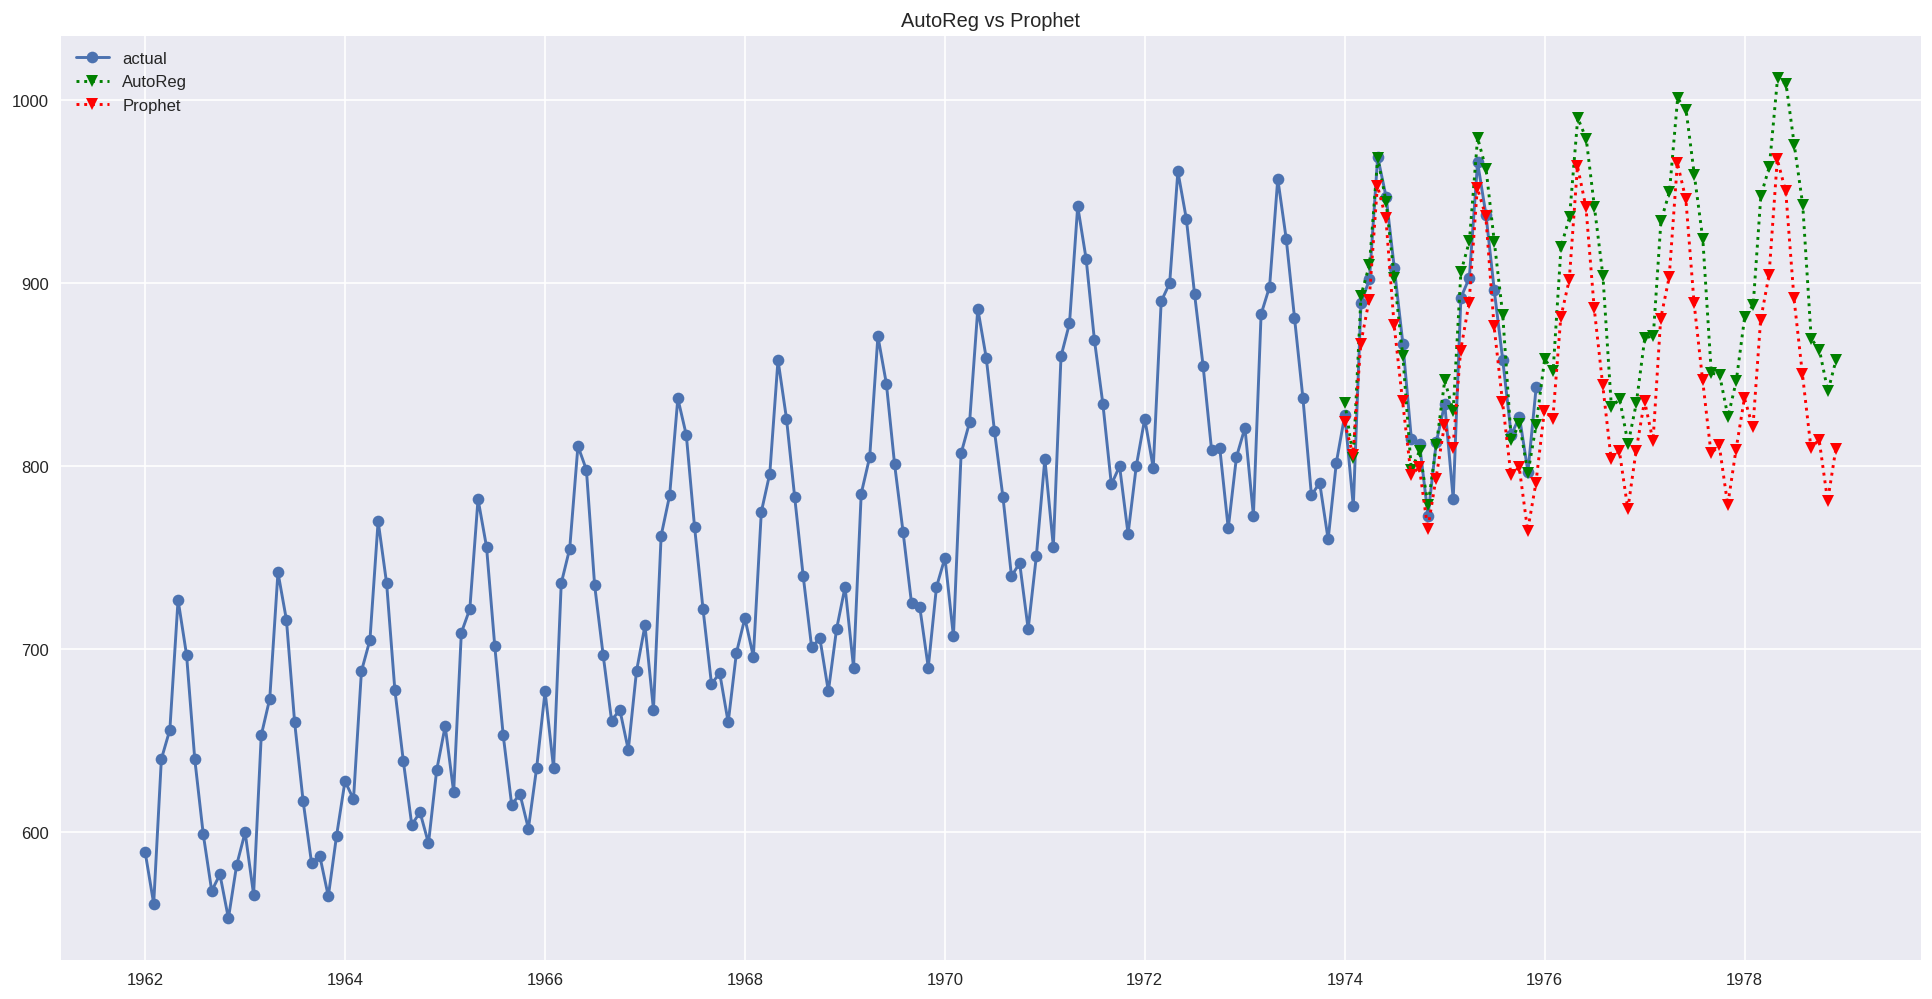

In [ ]:
plt.figure(figsize=(20, 10))
plt.plot(df['milk'], label='actual', marker='o')
plt.plot(pd.concat((ar_pred_test, ar_pred_future)), marker='v', color='g', linestyle=':', label='AutoReg')
plt.plot(pd.concat((forecast_test, forecast_future))['ds'], pd.concat((forecast_test, forecast_future))['yhat'], marker='v', color='r', linestyle=':', label='Prophet')
# plt.plot(triple_exp_fcast, color='r', label= f'TripleExp rmse = {triple_exp_rmse}')
# plt.plot(ar_fcast, color='g', label = f'AutoReg rmse = {ar_rmse}')


plt.legend()
plt.title(f'AutoReg vs Prophet');

### 4. Итог

In [ ]:
rmse_models_list = [moving_average_mae, weighted_moving_average_mae, ar_mae, prophet_mae_test]
rmse_list = pd.Series(
    index = ['Moving_average', 'Weighted_moving_average', 'AutoReg', 'Prophet'],
    data=rmse_models_list
)

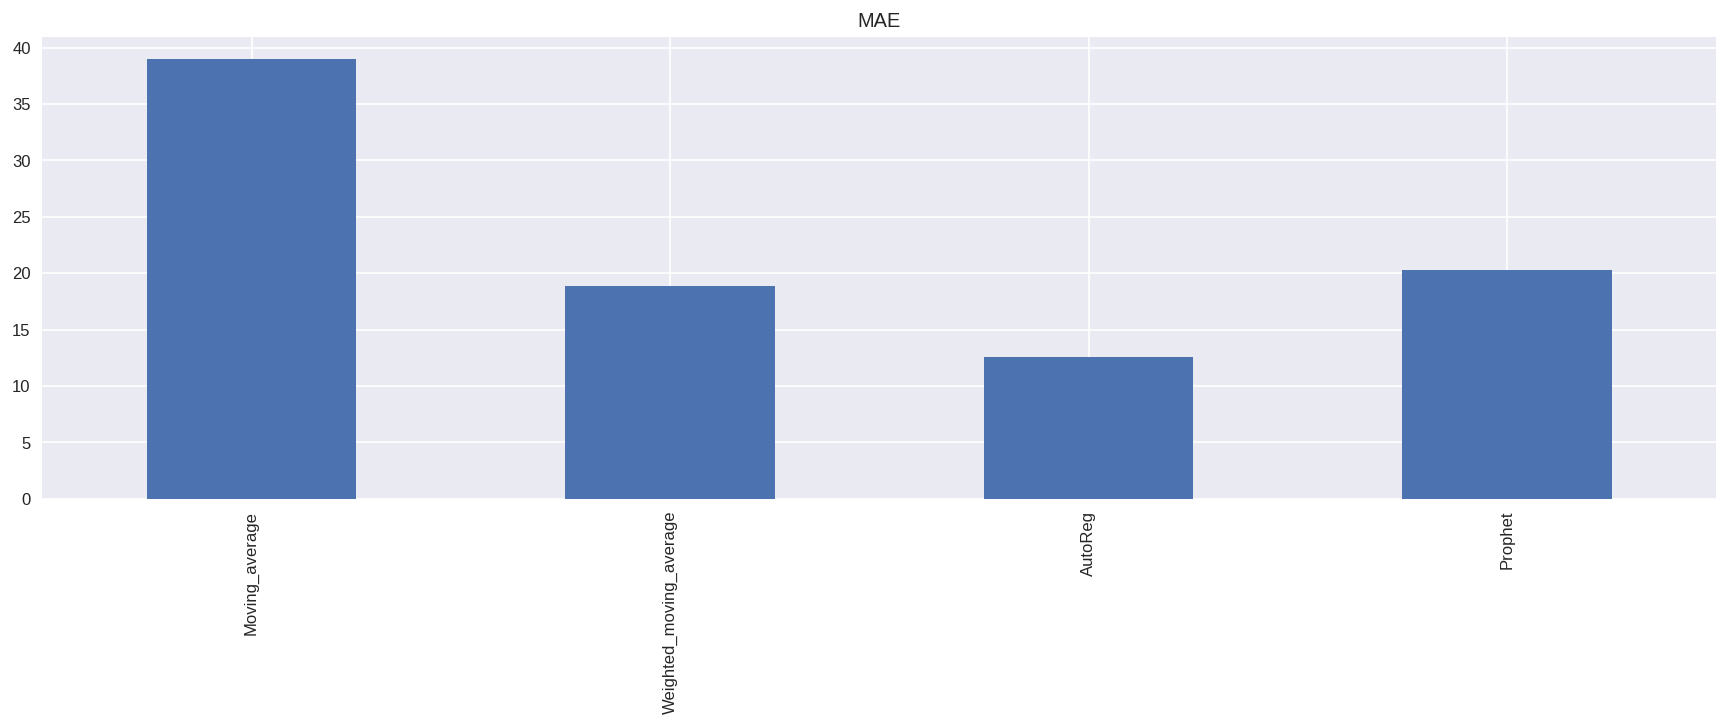

In [ ]:
rmse_list.plot.bar()
plt.title('MAE');

Еще ряд сильных библиотек по работе с временными рядами:  
* [Darts](https://habr.com/ru/articles/659405/)
* [Merlion](https://habr.com/ru/companies/sportmaster_lab/articles/792318/)
* [tsfresh](https://tsfresh.readthedocs.io/en/latest/)
* [Kats](https://github.com/facebookresearch/Kats)
* [autots](https://winedarksea.github.io/AutoTS/build/html/source/tutorial.html)